<a href="https://colab.research.google.com/github/EhsanGhasemi423/INFS-8368/blob/main/11_Forward_Backward_Propagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Forward Propagation, Backpropagation, and Computational Graphs**

In the previous sections, we trained multilayer perceptrons (MLPs) using TensorFlow. During training, the framework automatically computed gradients and updated the model parameters. However, understanding what happens behind the scenes is essential for understanding how neural networks learn.

This section explains the two main phases of training a neural network:

- **Forward propagation (forward pass):** Computes the model's prediction from the input.
- **Backpropagation (backward pass):** Computes gradients and updates the model's parameters to reduce prediction errors.

To explain these concepts, we consider a simple neural network with one hidden layer.

---

**Forward Propagation**

**Forward propagation** (also called the **forward pass**) is the process of passing the input through the neural network to produce an output prediction.

The computation proceeds layer by layer:

1. The input features are multiplied by the hidden-layer weights.
2. An activation function (such as ReLU) is applied.
3. The hidden-layer outputs are multiplied by the output-layer weights.
4. The network produces the final output (logits).
5. A loss function compares the prediction with the true label.

### Step 1: Compute the hidden layer

Let:

- $\mathbf{x}$ = input feature vector
- $\mathbf{W}^{(1)}$ = hidden-layer weight matrix

The hidden layer is computed as

$$
\mathbf{z}=\mathbf{W}^{(1)}\mathbf{x}
$$

where:

- $\mathbf{z}$ is the weighted input to the hidden layer.

### Step 2: Apply the activation function

The activation function introduces nonlinearity:

$$
\mathbf{h}=\phi(\mathbf{z})
$$

where:

- $\phi(\cdot)$ is an activation function such as ReLU.
- $\mathbf{h}$ represents the hidden-layer activations.

### Step 3: Compute the output layer

The hidden-layer activations become the input to the output layer:

$$
\mathbf{o}=\mathbf{W}^{(2)}\mathbf{h}
$$

where:

- $\mathbf{W}^{(2)}$ is the output-layer weight matrix.
- $\mathbf{o}$ contains the output logits.

### Step 4: Compute the loss

The model compares its prediction with the true label:

$$
L=l(\mathbf{o},y)
$$

where:

- $y$ is the correct label.
- $l(\cdot)$ is the loss function (such as cross-entropy).

The loss measures how far the prediction is from the correct answer.

### Step 5: Add regularization (optional)

To reduce overfitting, many models add a regularization penalty:

$$
J=L+s
$$

where:

- $L$ is the prediction loss.
- $s$ is the regularization term (for example, L2 regularization).
- $J$ is the final objective function minimized during training.

> **Note:** In this chapter, the main focus is understanding forward propagation. The regularization term is introduced here for completeness and will be discussed in more detail in later chapters.

**Computational Graph of Forward Propagation**

A **computational graph** is a visual representation of all the computations performed during the forward pass of a neural network. It shows how data flows from the input to the final output and how each operation depends on the previous one.

In a computational graph:

- **Rectangles (squares)** represent **variables** (inputs, weights, intermediate values, outputs, and loss).
- **Circles** represent **operations** (such as matrix multiplication, activation functions, addition, and loss computation).
- **Arrows** indicate the direction of data flow.

The forward pass follows these steps:

1. The input vector **x** is multiplied by the hidden-layer weights **W¹** to produce **z**.
2. The activation function **φ** (e.g., ReLU) is applied to **z** to produce the hidden activations **h**.
3. The hidden activations are multiplied by the output-layer weights **W²** to produce the output logits **o**.
4. The predicted output **o** is compared with the true label **y** to compute the loss **L**.
5. If regularization is used, the regularization term **s** is added to the loss to obtain the final objective function **J**.

The figure below illustrates the computational graph for forward propagation.

> **Why is this graph important?**
>
> Deep learning frameworks such as TensorFlow and PyTorch automatically build computational graphs during the forward pass. These graphs record every operation so that the framework can later compute gradients efficiently during **backpropagation**.
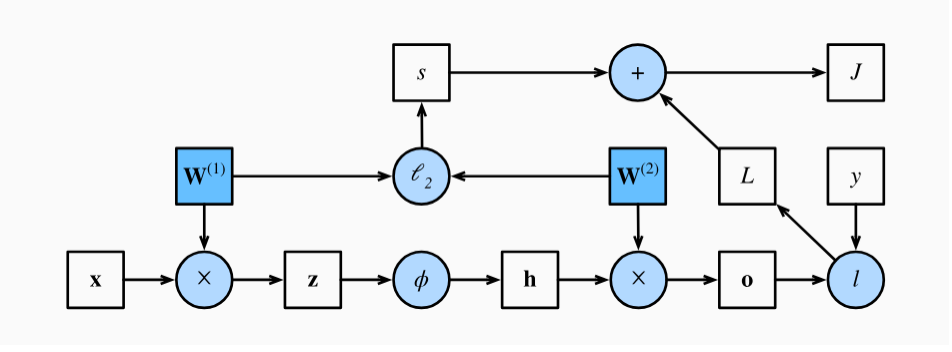

## **Backpropagation**

**Backpropagation** is the algorithm used to train a neural network. Its purpose is to compute the **gradients** of the objective function with respect to every trainable parameter (weights and biases). These gradients tell the optimizer how each parameter should be updated to reduce the error.

During training, the model minimizes the **objective function**:

$$
J = L + s
$$

where:

- \(L\) is the **loss**, which measures the difference between the model's predictions and the true labels.
- \(s\) is the **regularization term**, which helps reduce overfitting by penalizing large weights.
- \(J\) is the **objective function** that the optimizer aims to minimize.

Unlike **forward propagation**, which computes predictions from the input, **backpropagation** starts from the objective function and works backward through the network. It uses the **chain rule** from calculus to determine how much each weight and bias contributed to the final error.

The training process consists of four steps:

1. **Forward propagation:** Pass the input through the network to compute the prediction.
2. **Compute the objective function:** Calculate the prediction loss and add the regularization term (if used).
3. **Backpropagation:** Compute the gradients of the objective function with respect to every weight and bias.
4. **Update the parameters:** Use an optimizer (such as Gradient Descent) to update the weights and biases.

The overall workflow is shown below:

```text
Input
   ↓
Forward Propagation
   ↓
Prediction
   ↓
Objective Function (J)
   ↓
Backpropagation
   ↓
Gradients
   ↓
Update Weights & Biases
```

### Key Takeaway

- **Forward propagation** computes the model's predictions.
- **Backpropagation** computes the gradients needed to update the model's parameters.
- Modern deep learning frameworks such as **TensorFlow** and **PyTorch** perform backpropagation automatically using **automatic differentiation**, so we rarely implement the underlying equations by hand.



### Why are forward and backpropagation connected?

Backpropagation depends on the values computed during forward propagation. For example, the hidden-layer activations and output logits produced during the forward pass are reused when computing gradients.

Because these intermediate values must be stored until backpropagation finishes, **training requires more memory than making predictions (inference)**. As neural networks become deeper or batch sizes become larger, memory usage also increases.

## Summary

In this section, we learned how neural networks are trained using **forward propagation** and **backpropagation**.

- **Forward propagation** passes the input through the network to compute predictions.
- **Backpropagation** computes the gradients of the objective function with respect to the model's parameters.
- The optimizer uses these gradients to update the weights and biases, reducing the objective function over time.
- During training, intermediate values from the forward pass are stored and reused during backpropagation, making training more memory-intensive than inference.

Modern deep learning frameworks such as **TensorFlow** and **PyTorch** perform backpropagation automatically through **automatic differentiation**, allowing us to focus on designing and training neural networks rather than manually deriving gradients.